In [1]:
from simfile import SimFile
from simulation import Simulation
from validation import switchOffAllEffects, fitGaussian2D
import os
import matplotlib.pyplot as plt
import referenceFrames as rf
import numpy as np
import math
from scipy import constants

In [2]:
sim = Simulation("BFE")
switchOffAllEffects(sim)
sim.outputDir = os.environ["PLATO_WORKDIR"]

# One full-frame exposure

sim["ObservingParameters/NumExposures"] = 1
sim["CCD/IncludeConvolution"] = "yes"

starCatalogFilename = os.environ["PLATO_WORKDIR"] + "generatedFromPixelCoordinates.starcat"
sim["ObservingParameters/StarCatalogFile"] = starCatalogFilename

dim = 9
sim["SubField/NumRows"] = dim
sim["SubField/NumColumns"] = dim

sim["ControlHDF5Content/WriteSubPixelImages"] = "yes"
numSubPixels = sim["SubField/SubPixels"]

sim["PSF/Model"] = "MappedGaussian"
sigma = sim["PSF/MappedGaussian/Sigma"]

In [3]:
magnitudes = np.arange(8, 20, 0.5)
position = dim / 2

In [4]:
sim["CCD/IncludeBFE"] = "yes"

widthWithBFE = np.array([])
totalFluxWithBFE = np.array([])
    
for magnitude in magnitudes:

    sim.createStarCatalogFileFromPixelCoordinates(np.array([position]), np.array([position]), np.array([magnitude]), np.array([1]), starCatalogFilename)

    output = sim.run(removeOutputFile = True)
    image = output.getImage(0)
    
    params = fitGaussian2D(image, np.max(image), dim / 2, dim / 2, sigma, sigma, subtractConstant = True)
    widthWithBFE = np.append(widthWithBFE, params[3])
    
    totalFluxWithBFE = np.append(totalFluxWithBFE, np.sum(image))

In [5]:
sim["CCD/IncludeBFE"] = "no"

widthWithoutBFE = np.array([])
totalFluxWithoutBFE = np.array([])
    
for magnitude in magnitudes:

    sim.createStarCatalogFileFromPixelCoordinates(np.array([position]), np.array([position]), np.array([magnitude]), np.array([1]), starCatalogFilename)

    output = sim.run(removeOutputFile = True)
    image = output.getImage(0)
    
    params = fitGaussian2D(image, np.max(image), dim / 2, dim / 2, sigma, sigma, subtractConstant = True)
    widthWithoutBFE = np.append(widthWithoutBFE, params[3])
    
    totalFluxWithoutBFE = np.append(totalFluxWithoutBFE, np.sum(image))

Text(0, 0.5, '$\\sigma$ [pixels]')

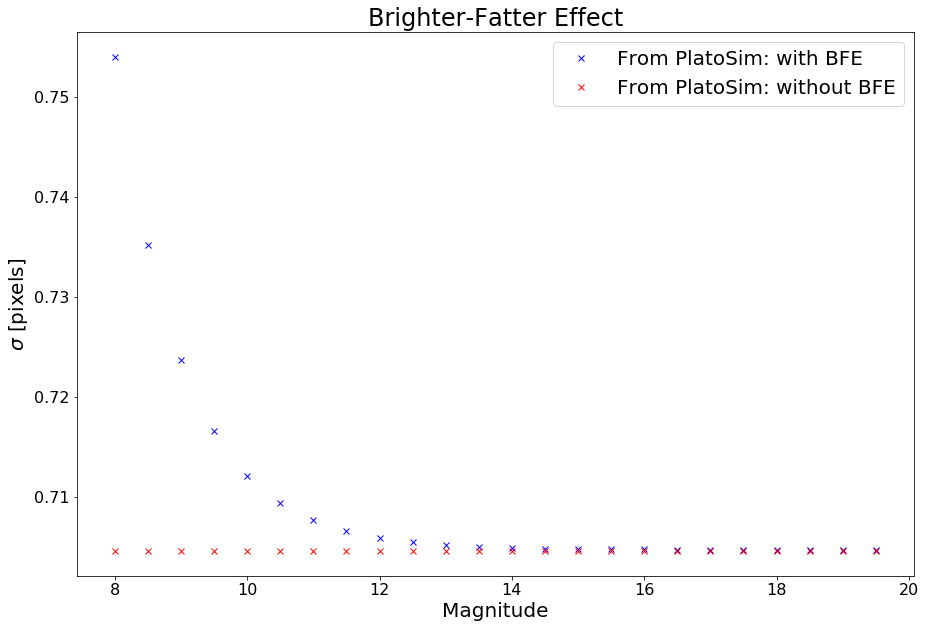

In [6]:
fig = plt.figure(figsize = (15, 10))
ax = fig.add_subplot(1, 1, 1)



###############
# From PlatoSim
###############

plt.plot(magnitudes, widthWithBFE, "bx", label = "From PlatoSim: with BFE")
plt.plot(magnitudes, widthWithoutBFE, "rx", label = "From PlatoSim: without BFE")



########
# Layout
########

plt.title("Brighter-Fatter Effect", fontsize = 24)
plt.legend(loc='best', fontsize = 20)

for tick in ax.xaxis.get_major_ticks():
    tick.label.set_fontsize(16)
    
for tick in ax.yaxis.get_major_ticks():
    tick.label.set_fontsize(16)
    
plt.xlabel("Magnitude", fontsize = 20)
plt.ylabel("$\sigma$ [pixels]", fontsize = 20)

Text(0, 0.5, 'Total flux [e-]')

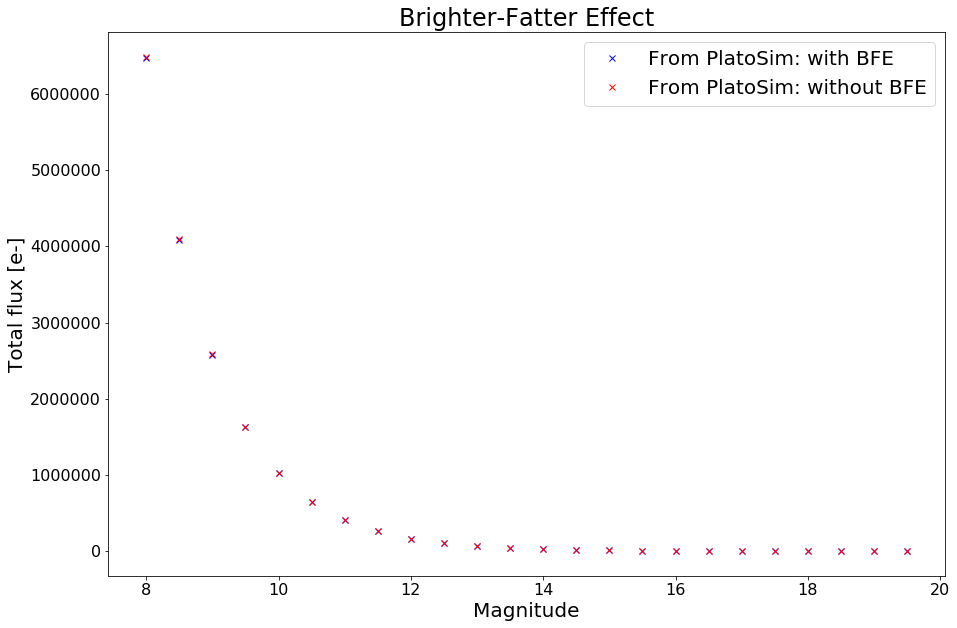

In [7]:
fig = plt.figure(figsize = (15, 10))
ax = fig.add_subplot(1, 1, 1)



###############
# From PlatoSim
###############

plt.plot(magnitudes, totalFluxWithBFE, "bx", label = "From PlatoSim: with BFE")
plt.plot(magnitudes, totalFluxWithoutBFE, "rx", label = "From PlatoSim: without BFE")



########
# Layout
########

plt.title("Brighter-Fatter Effect", fontsize = 24)
plt.legend(loc='best', fontsize = 20)

for tick in ax.xaxis.get_major_ticks():
    tick.label.set_fontsize(16)
    
for tick in ax.yaxis.get_major_ticks():
    tick.label.set_fontsize(16)
    
plt.xlabel("Magnitude", fontsize = 20)
plt.ylabel("Total flux [e-]", fontsize = 20)